============================================================
# CELL 1: SETUP ENVIRONMENT
============================================================

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import urllib.request

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seed untuk reproduksibilitas
torch.manual_seed(42)
np.random.seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
✅ Environment setup complete!
PyTorch version: 2.11.0+cpu


============================================================
# CELL 2: LOAD DATASET MNIST
============================================================

📁 Mounting Google Drive...
Mounted at /content/drive

📂 Checking dataset paths...
   Training path: /content/drive/MyDrive/dataset/MNIST/training
   Testing path: /content/drive/MyDrive/dataset/MNIST/testing
✅ Dataset folders found!

CELL 2: LOAD CUSTOM DATASET FROM GOOGLE DRIVE

📥 Loading dataset from: /content/drive/MyDrive/dataset/MNIST/training
   Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Class 0: 5933 images
   Class 1: 6752 images
   Class 2: 5958 images
   Class 3: 6141 images
   Class 4: 5842 images
   Class 5: 5441 images
   Class 6: 5928 images
   Class 7: 6285 images
   Class 8: 5851 images
   Class 9: 5959 images
   Total images loaded: 60090

📥 Loading dataset from: /content/drive/MyDrive/dataset/MNIST/testing
   Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Class 0: 980 images
   Class 1: 1135 images
   Class 2: 1032 images
   Class 3: 1010 images
   Class 4: 982 images
   Class 5: 892 images
   Class 6: 958 images
   Clas

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


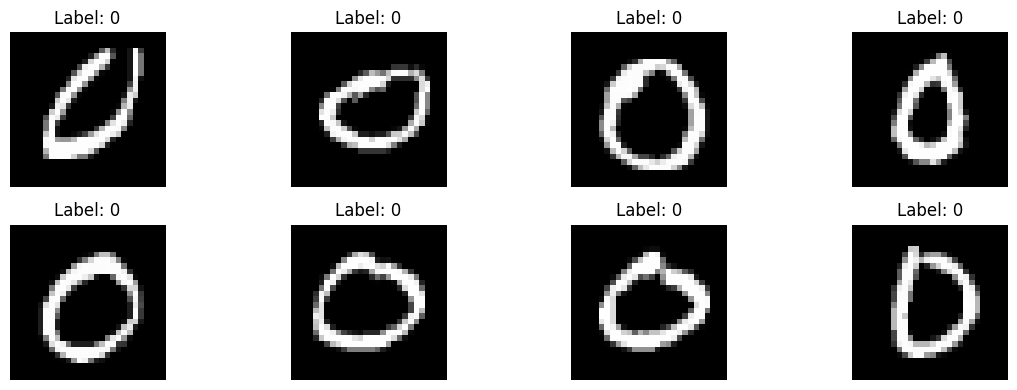


📊 Dataset Information:
   Training classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Testing classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   Image size: 28x28 pixels (grayscale)

✅ CELL 2 COMPLETED!


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
print("📁 Mounting Google Drive...")
drive.mount('/content/drive')

# ============================================================
# 1. Tentukan Path ke Dataset di Drive
# ============================================================

# Ganti path ini sesuai dengan lokasi folder dataset Anda di Drive
# Contoh: '/content/drive/MyDrive/Colab_Projects/handwritten_dataset/'
DATASET_PATH = '/content/drive/MyDrive/dataset/MNIST/'  # ← SESUAIKAN!

TRAIN_PATH = os.path.join(DATASET_PATH, 'training')
TEST_PATH = os.path.join(DATASET_PATH, 'testing')

# Cek apakah folder ada
print(f"\n📂 Checking dataset paths...")
print(f"   Training path: {TRAIN_PATH}")
print(f"   Testing path: {TEST_PATH}")

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"❌ Training folder tidak ditemukan di: {TRAIN_PATH}")
if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"❌ Testing folder tidak ditemukan di: {TEST_PATH}")

print("✅ Dataset folders found!")

# ============================================================
# 2. Custom Dataset Class
# ============================================================

class HandwrittenDigitDataset(Dataset):
    """
    Dataset untuk gambar tulisan tangan angka 0-9
    Struktur folder:
        training/
            0/
                img1.png
                img2.png
            ...
            9/
                img1.png
        testing/
            0/
                ...
            9/
                ...
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: int(cls) for cls in self.classes}  # Angka 0-9

        self.images = []
        self.labels = []

        print(f"\n📥 Loading dataset from: {root_dir}")
        print(f"   Classes found: {self.classes}")

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            class_label = self.class_to_idx[class_name]

            # Cari semua file gambar di folder kelas
            image_files = [f for f in os.listdir(class_dir)
                          if f.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            for img_file in image_files:
                self.images.append(os.path.join(class_dir, img_file))
                self.labels.append(class_label)

            print(f"   Class {class_name}: {len(image_files)} images")

        print(f"   Total images loaded: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Load image dengan PIL
        image = Image.open(img_path).convert('L')  # Grayscale

        # Resize ke 28x28 (standar MNIST) jika perlu
        if image.size != (28, 28):
            image = image.resize((28, 28), Image.Resampling.LANCZOS)

        # Apply transformasi
        if self.transform:
            image = self.transform(image)

        return image, label

# ============================================================
# 3. Fungsi Load Dataset
# ============================================================

def load_custom_dataset(batch_size=128, num_train_samples=None, num_test_samples=None):
    """
    Load dataset dari Google Drive

    Args:
        batch_size: Ukuran batch
        num_train_samples: Jumlah sampel training (None = semua)
        num_test_samples: Jumlah sampel testing (None = semua)
    """
    # Transformasi untuk data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalisasi ke [-1, 1]
    ])

    # Load dataset
    train_dataset = HandwrittenDigitDataset(TRAIN_PATH, transform=transform)
    test_dataset = HandwrittenDigitDataset(TEST_PATH, transform=transform)

    # Ambil subset jika diperlukan
    if num_train_samples and num_train_samples < len(train_dataset):
        indices = torch.randperm(len(train_dataset))[:num_train_samples]
        train_dataset = torch.utils.data.Subset(train_dataset, indices)
        print(f"   Using subset of training: {len(train_dataset)} samples")

    if num_test_samples and num_test_samples < len(test_dataset):
        indices = torch.randperm(len(test_dataset))[:num_test_samples]
        test_dataset = torch.utils.data.Subset(test_dataset, indices)
        print(f"   Using subset of testing: {len(test_dataset)} samples")

    # Buat DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"\n✅ Dataset loaded!")
    print(f"   Training samples: {len(train_dataset)}")
    print(f"   Testing samples: {len(test_dataset)}")

    return train_loader, test_loader, train_dataset, test_dataset

# ============================================================
# 4. EKSEKUSI
# ============================================================

print("\n" + "="*50)
print("CELL 2: LOAD CUSTOM DATASET FROM GOOGLE DRIVE")
print("="*50)

# Load dataset
train_loader, test_loader, train_dataset, test_dataset = load_custom_dataset(
    batch_size=128,
    num_train_samples=None,  # Gunakan semua data training
    num_test_samples=None     # Gunakan semua data testing
)

# ============================================================
# 5. VISUALISASI SAMPLE
# ============================================================

def show_samples(loader, num_samples=8):
    """
    Menampilkan sample gambar dari dataset
    """
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 4))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i+1)
        # Denormalize dari [-1,1] ke [0,1] untuk ditampilkan
        img = images[i].squeeze().numpy()
        img = (img + 1) / 2  # Kembali ke rentang [0,1]
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Cek sample pertama
print("\n🖼️ Sample images from dataset:")
show_samples(test_loader, num_samples=8)

# ============================================================
# 6. INFORMASI DATASET
# ============================================================

print("\n📊 Dataset Information:")
print(f"   Training classes: {train_dataset.classes if hasattr(train_dataset, 'classes') else 'N/A'}")
print(f"   Testing classes: {test_dataset.classes if hasattr(test_dataset, 'classes') else 'N/A'}")
print(f"   Image size: 28x28 pixels (grayscale)")

print("\n✅ CELL 2 COMPLETED!")

============================================================
# CELL 3: CREATE LENET MODEL (ATAU TRAINING DARI AWAL)
============================================================

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import time
import os
from google.colab import drive

# --- 1. Persiapan Path Drive ---
drive.mount('/content/drive')
model_dir = '/content/drive/MyDrive/model'
model_path = os.path.join(model_dir, 'final_lenet_mnist.pth')
os.makedirs(model_dir, exist_ok=True)

# --- 2. Load Dataset (MNIST) ---
print("Menyiapkan dataset...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# --- 3. Definisi Model LeNet-5 ---
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)

# Variabel histori
training_history = {'loss': [], 'accuracy': []}

# --- 4. Cek Model di Drive ---
if os.path.exists(model_path):
    print(f"\n✅ Menemukan model di {model_path}. Memuat model dan histori...")
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    if 'history' in checkpoint:
        training_history = checkpoint['history']
        print(f"✅ Histori lengkap ditemukan ({len(training_history['accuracy'])} epoch):")
        for i, (acc, loss) in enumerate(zip(training_history['accuracy'], training_history['loss'])):
            print(f"   Epoch {i+1}: Accuracy = {acc:.2f}%, Loss = {loss:.4f}")
    else:
        print("⚠️ Model dimuat tetapi data histori per epoch tidak ditemukan.")

    print("\nModel berhasil dimuat. Melewati proses training.")
else:
    print("\n❌ Model tidak ditemukan di Drive. Memulai training dari awal...")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 5

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for batch_idx, (data, target) in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Evaluasi
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == target).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / len(test_dataset)

        training_history['loss'].append(epoch_loss)
        training_history['accuracy'].append(epoch_acc)

        print(f'\nEpoch {epoch+1} selesai. Avg Loss: {epoch_loss:.4f}, Test Akurasi: {epoch_acc:.2f}%')

    # Simpan ke Drive
    print(f"\n💾 Menyimpan model dan histori lengkap ke {model_path}...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'history': training_history
    }, model_path)
    print("✅ Model dan histori berhasil disimpan!")

# Final Summary
if training_history['accuracy']:
    print(f"\n--- Ringkasan Training ---")
    print(f"Total Epoch: {len(training_history['accuracy'])}")
    print(f"Final Accuracy: {training_history['accuracy'][-1]:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Menyiapkan dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.01MB/s]



✅ Menemukan model di /content/drive/MyDrive/model/final_lenet_mnist.pth. Memuat model dan histori...
✅ Histori lengkap ditemukan (5 epoch):
   Epoch 1: Accuracy = 96.90%, Loss = 0.2706
   Epoch 2: Accuracy = 98.19%, Loss = 0.0790
   Epoch 3: Accuracy = 98.64%, Loss = 0.0561
   Epoch 4: Accuracy = 98.95%, Loss = 0.0435
   Epoch 5: Accuracy = 98.80%, Loss = 0.0367

Model berhasil dimuat. Melewati proses training.

--- Ringkasan Training ---
Total Epoch: 5
Final Accuracy: 98.80%


============================================================
# CELL 4: IMPLEMENTASI FGQ TERNARY QUANTIZATION
============================================================

## Fine-Grained Quantization Ternary

In [ ]:
def ternary_quantize_group(weight_tensor, group_size=4):
    """
    Melakukan ternary quantization per group (FGQ)

    Args:
        weight_tensor: Tensor bobot
        group_size (N): Jumlah bobot per kelompok

    Returns:
        ternary_weights: Bobot ternary {-alpha, 0, +alpha}
        alphas: Faktor skala per kelompok
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()

    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []

    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        group_size_actual = len(group)

        if group_size_actual == 0:
            continue

        abs_group = torch.abs(group)

        # Jika semua bobot 0
        if abs_group.max().item() == 0:
            alphas.append(0.0)
            continue

        # Cari threshold optimal (20 kandidat)
        thresholds = torch.linspace(
            abs_group.min().item(),
            abs_group.max().item(),
            steps=20
        )

        best_delta = 0
        best_score = -float('inf')

        for delta in thresholds:
            mask = abs_group > delta
            if mask.sum() == 0:
                continue
            sum_abs = abs_group[mask].sum()
            count = mask.sum().float()
            score = (sum_abs ** 2) / count
            if score > best_score:
                best_score = score
                best_delta = delta

        # Hitung alpha
        mask = abs_group > best_delta
        if mask.sum() == 0:
            alphas.append(0.0)
            continue

        alpha = abs_group[mask].sum() / mask.sum().float()
        alphas.append(alpha.item())

        # Buat ternary weights
        ternary_group = torch.zeros_like(group)
        ternary_group[group > best_delta] = alpha
        ternary_group[group < -best_delta] = -alpha

        ternary_flat[i:min(i+group_size, n)] = ternary_group

    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, verbose=True):
    """
    Menerapkan FGQ ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying FGQ with N={group_size}...")
    alpha_means = []
    layer_names = []
    total_params = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data
            total_params += original_weight.numel()

            ternary_weight, alphas = ternary_quantize_group(
                original_weight,
                group_size=group_size
            )
            module.weight.data = ternary_weight

            alpha_mean = np.mean(alphas) if alphas else 0
            alpha_means.append(alpha_mean)
            layer_names.append(name)

            if verbose:
                num_groups = original_weight.numel() // group_size if group_size > 0 else 0
                print(f"  ✓ {name}: {original_weight.shape}, "
                      f"groups={num_groups}, α_mean={alpha_mean:.4f}")

    print(f"   Total parameters quantized: {total_params:,}")
    return model, alpha_means, layer_names

print("\n" + "="*50)
print("CELL 5: FGQ IMPLEMENTATION READY")
print("="*50)

print("✅ FGQ functions defined!")
print("   - ternary_quantize_group(): quantize per group")
print("   - apply_fgq_to_model(): apply to entire model")


CELL 5: FGQ IMPLEMENTATION READY
✅ FGQ functions defined!
   - ternary_quantize_group(): quantize per group
   - apply_fgq_to_model(): apply to entire model


## Standard Quantization Ternary

In [ ]:
def standard_ternary_quantize(weight_tensor):
    """
    Melakukan standard ternary quantization pada seluruh tensor bobot
    (Global quantization, bukan per group/fine-grained)
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    abs_weights = torch.abs(flat_weights)

    # Jika semua bobot 0
    if abs_weights.max().item() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Mencari threshold optimal secara global (berdasarkan rata-rata absolut)
    # Metode umum: delta = 0.7 * E[|W|]
    delta = 0.7 * torch.mean(abs_weights)

    # Hitung mask untuk nilai yang lebih besar dari threshold
    mask = abs_weights > delta

    if mask.sum() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Hitung alpha (skala) global
    alpha = abs_weights[mask].sum() / mask.sum().float()

    # Buat ternary weights
    ternary_flat = torch.zeros_like(flat_weights)
    ternary_flat[flat_weights > delta] = alpha
    ternary_flat[flat_weights < -delta] = -alpha

    return ternary_flat.reshape(original_shape), alpha.item()

def apply_standard_ternary_to_model(model, verbose=True):
    """
    Menerapkan Standard Ternary Quantization ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying Standard Ternary Quantization (Global)...")
    layer_alphas = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data

            ternary_weight, alpha = standard_ternary_quantize(original_weight)
            module.weight.data = ternary_weight

            layer_alphas.append(alpha)

            if verbose:
                print(f"  ✓ {name}: {original_weight.shape}, α={alpha:.4f}")

    return model, layer_alphas

print("\n" + "="*50)
print("CELL 5.1: STANDARD TERNARY QUANTIZATION READY")
print("="*50)
print("✅ Standard Ternary functions defined!")


CELL 5.1: STANDARD TERNARY QUANTIZATION READY
✅ Standard Ternary functions defined!


============================================================
# CELL 5: SKENARIO A - DENGAN FINE-GRAINED QUANTIZATION ============================================================

📊 Mengambil Baseline Accuracy dari model LeNet-5 di memori...

CELL 6: SKENARIO A - TANPA FINE-TUNING (LeNet-5)

📊 Baseline accuracy (FP32): 98.80%

Testing N = 2

🔧 Applying FGQ with N=2...
  ✓ conv1: torch.Size([6, 1, 5, 5]), groups=75, α_mean=0.2338
  ✓ conv2: torch.Size([16, 6, 5, 5]), groups=1200, α_mean=0.1198
  ✓ fc1: torch.Size([120, 400]), groups=24000, α_mean=0.0718
  ✓ fc2: torch.Size([84, 120]), groups=5040, α_mean=0.0893
  ✓ fc3: torch.Size([10, 84]), groups=420, α_mean=0.1288
   Total parameters quantized: 61,470

📊 Evaluating FGQ model (without fine-tuning)...

✅ FGQ N=2 Top-1 Accuracy: 96.23%
   Drop from baseline: 2.57%

Testing N = 4

🔧 Applying FGQ with N=4...
  ✓ conv1: torch.Size([6, 1, 5, 5]), groups=37, α_mean=0.2379
  ✓ conv2: torch.Size([16, 6, 5, 5]), groups=600, α_mean=0.1253
  ✓ fc1: torch.Size([120, 400]), groups=12000, α_mean=0.0777
  ✓ fc2: torch.Size([84, 120]), groups=2520, α_mean=0.0946
  ✓ fc3: torch.Size([10, 84]), groups=210, α_mean=0.1309
   Total 

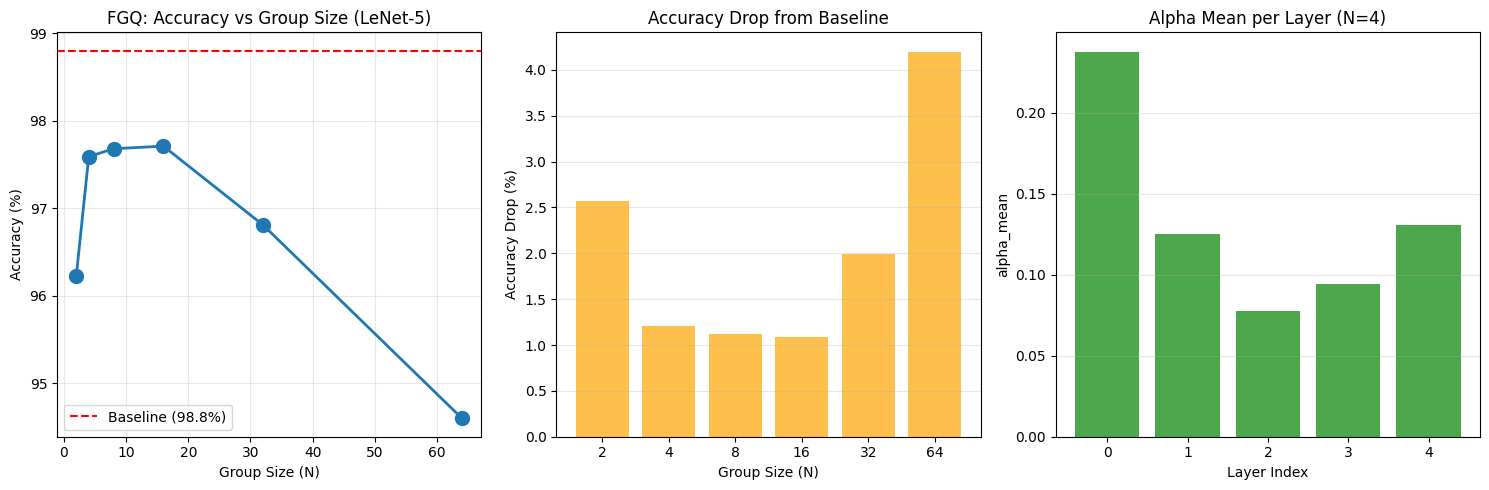


✅ CELL 6 COMPLETED!


In [ ]:
def evaluate_accuracy(model, data_loader, verbose=False):
    """
    Evaluasi akurasi model
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            # Support untuk LeNet5 yang menerima input 4D (B, C, H, W)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

# --- Persiapan Baseline ---
# Karena kita tidak menggunakan Drive, kita ambil model yang sudah terlatih di memori
print("📊 Mengambil Baseline Accuracy dari model LeNet-5 di memori...")
baseline_acc = evaluate_accuracy(model, test_loader)

# Simpan state awal untuk reset selama testing
import copy
baseline_state = copy.deepcopy(model.state_dict())

# Eksekusi Skenario
print("\n" + "="*50)
print("CELL 6: SKENARIO A - TANPA FINE-TUNING (LeNet-5)")
print("="*50)

print(f"\n📊 Baseline accuracy (FP32): {baseline_acc:.2f}%")

# Test dengan berbagai group size
group_sizes = [2, 4, 8, 16, 32, 64]
results = {'N': [], 'accuracy': [], 'drop': [], 'alpha_means': []}

for N in group_sizes:
    print(f"\n{'='*40}")
    print(f"Testing N = {N}")
    print(f"{'='*40}")

    # Reset model ke baseline menggunakan state_dict
    test_model = LeNet5().to(device)
    test_model.load_state_dict(baseline_state)
    test_model.eval()

    # Apply FGQ
    test_model, alpha_means, layer_names = apply_fgq_to_model(test_model, group_size=N, verbose=True)

    # Evaluasi
    print("\n📊 Evaluating FGQ model (without fine-tuning)...")
    acc = evaluate_accuracy(test_model, test_loader, verbose=True)

    drop = baseline_acc - acc
    print(f"\n✅ FGQ N={N} Top-1 Accuracy: {acc:.2f}%")
    print(f"   Drop from baseline: {drop:.2f}%")

    results['N'].append(N)
    results['accuracy'].append(acc)
    results['drop'].append(drop)
    results['alpha_means'].append(alpha_means)

# Visualisasi hasil
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy vs Group Size
plt.subplot(1, 3, 1)
plt.plot(results['N'], results['accuracy'], marker='o', linewidth=2, markersize=10)
plt.axhline(y=baseline_acc, color='r', linestyle='--',
            label=f'Baseline ({baseline_acc:.1f}%)')
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy (%)')
plt.title('FGQ: Accuracy vs Group Size (LeNet-5)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Drop in Accuracy
plt.subplot(1, 3, 2)
plt.bar([str(n) for n in results['N']], results['drop'], color='orange', alpha=0.7)
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy Drop (%)')
plt.title('Accuracy Drop from Baseline')
plt.grid(True, alpha=0.3, axis='y')

# Plot 3: Alpha Mean per Layer (N=4, index 1)
plt.subplot(1, 3, 3)
if len(results['alpha_means']) > 1:
    alpha_means_4 = results['alpha_means'][1]  # Index 1 untuk N=4
    plt.bar(range(len(alpha_means_4)), alpha_means_4, alpha=0.7, color='green')
    plt.xlabel('Layer Index')
    plt.ylabel('alpha_mean')
    plt.title(f'Alpha Mean per Layer (N=4)')
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✅ CELL 6 COMPLETED!")

============================================================
# CELL 6: SKENARIO B - DENGAN STANDARD QUANTIZATION
============================================================


CELL 7: SKENARIO C - STANDARD TERNARY QUANTIZATION
📊 Baseline accuracy (FP32): 98.80%

🔧 Applying Standard Ternary Quantization (Global)...
  ✓ conv1: torch.Size([6, 1, 5, 5]), α=0.2395
  ✓ conv2: torch.Size([16, 6, 5, 5]), α=0.1340
  ✓ fc1: torch.Size([120, 400]), α=0.0802
  ✓ fc2: torch.Size([84, 120]), α=0.0922
  ✓ fc3: torch.Size([10, 84]), α=0.1290

📊 Evaluating Standard Ternary model...

✅ Standard Ternary Top-1 Accuracy: 95.46%
   Drop from baseline: 3.34%


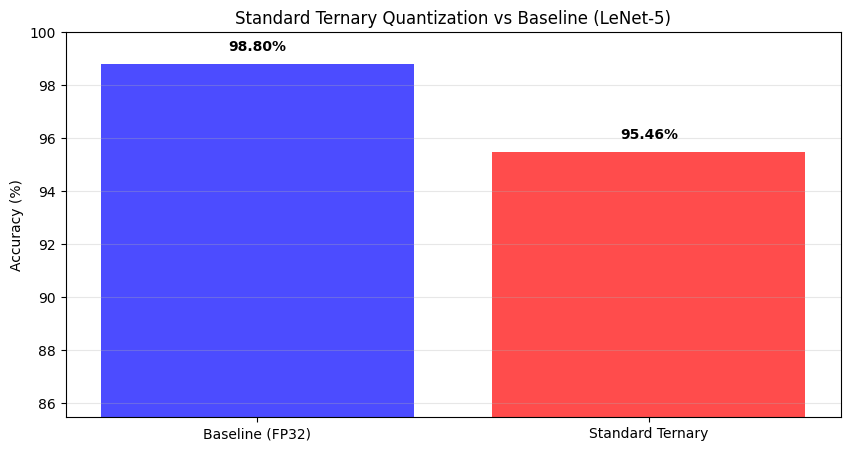


----------------------------------------
📝 Technical Summary:
   - Quantization Level: 2-bit (Ternary)
   - Granularity: Global (Per Layer)
   - Final Accuracy: 95.46%
   - Accuracy Drop: 3.34%
----------------------------------------

✅ CELL 7 COMPLETED!


In [ ]:
print("\n" + "="*50)
print("CELL 7: SKENARIO C - STANDARD TERNARY QUANTIZATION")
print("="*50)

# 1. Gunakan baseline model dari memori (LeNet-5)
print(f"📊 Baseline accuracy (FP32): {baseline_acc:.2f}%")

# Inisialisasi model baru dan muat state baseline
model_st = LeNet5().to(device)
model_st.load_state_dict(baseline_state)
model_st.eval()

# 2. Terapkan Standard Ternary Quantization (Global)
# Fungsi ini didefinisikan di Cell 5.1
model_st, layer_alphas = apply_standard_ternary_to_model(model_st, verbose=True)

# 3. Evaluasi Akurasi
print("\n📊 Evaluating Standard Ternary model...")
acc_st = evaluate_accuracy(model_st, test_loader, verbose=False)

drop_st = baseline_acc - acc_st

print(f"\n✅ Standard Ternary Top-1 Accuracy: {acc_st:.2f}%")
print(f"   Drop from baseline: {drop_st:.2f}%")

# 4. Visualisasi Perbandingan (Standard vs Baseline)
plt.figure(figsize=(10, 5))

labels = ['Baseline (FP32)', 'Standard Ternary']
accuracies = [baseline_acc, acc_st]
colors = ['blue', 'red']

plt.bar(labels, accuracies, color=colors, alpha=0.7)
plt.ylabel('Accuracy (%)')
plt.title('Standard Ternary Quantization vs Baseline (LeNet-5)')
plt.ylim(max(0, min(accuracies) - 10), 100)
plt.grid(True, axis='y', alpha=0.3)

# Tambahkan teks nilai
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontweight='bold')

plt.show()

# 5. Ringkasan Teknis
print("\n" + "-"*40)
print(f"📝 Technical Summary:")
print(f"   - Quantization Level: 2-bit (Ternary)")
print(f"   - Granularity: Global (Per Layer)")
print(f"   - Final Accuracy: {acc_st:.2f}%")
print(f"   - Accuracy Drop: {drop_st:.2f}%")
print("-"*40)

print("\n✅ CELL 7 COMPLETED!")

============================================================
# CELL 7: PERBANDINGAN SKENARIO A vs B
============================================================


CELL 8: PERBANDINGAN AKURASI TERBAIK


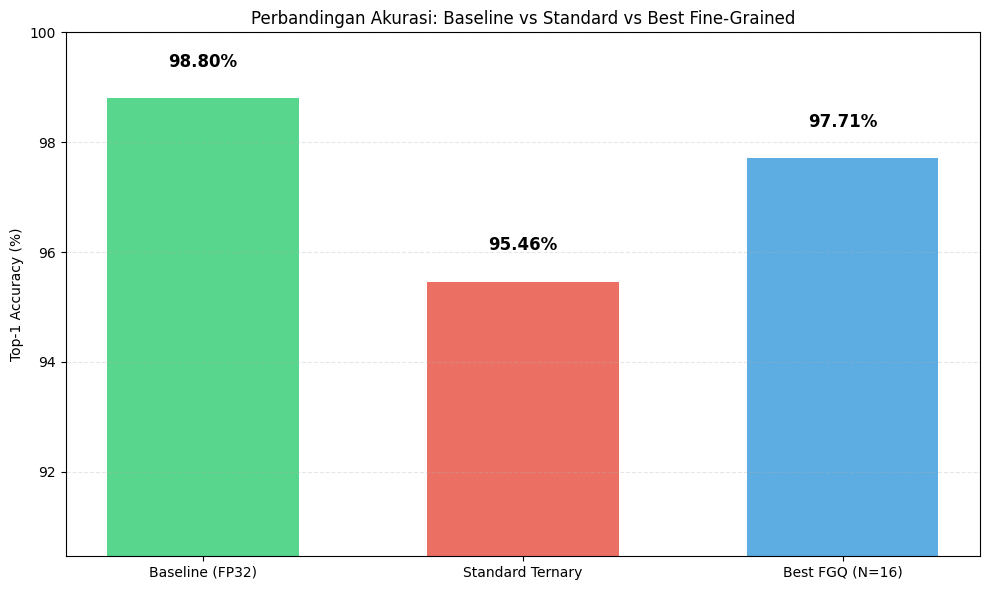


RINGKASAN PERBANDINGAN
1. Akurasi Baseline (FP32)  : 98.80%
2. Akurasi Standard Ternary : 95.46% (Drop: 3.34%)
3. Akurasi Terbaik FGQ (N=16): 97.71% (Drop: 1.09%)

💡 Kesimpulan Utama:
✔ FGQ dengan N=16 memberikan hasil yang paling mendekati model asli (FP32).
✔ Bar chart di atas menunjukkan bahwa pendekatan Fine-Grained jauh lebih efektif
   dalam mempertahankan akurasi dibandingkan pendekatan Standard (Global) pada level ternary.

✅ ANALISIS PERBANDINGAN SELESAI!


In [ ]:
print("\n" + "="*50)
print("CELL 8: PERBANDINGAN AKURASI TERBAIK")
print("="*50)

# Ambil akurasi terbaik dari FGQ
best_fgq_acc = max(results['accuracy'])
best_n = results['N'][results['accuracy'].index(best_fgq_acc)]

# Data untuk bar chart
labels = ['Baseline (FP32)', 'Standard Ternary', f'Best FGQ (N={best_n})']
values = [baseline_acc, acc_st, best_fgq_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(10, 6))

# Membuat bar chart
bars = plt.bar(labels, values, color=colors, alpha=0.8, width=0.6)

# Dekorasi Plot
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Perbandingan Akurasi: Baseline vs Standard vs Best Fine-Grained')
plt.ylim(max(0, min(values) - 5), 100)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# Tambahkan label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# --- Insight & Kesimpulan ---
print("\n" + "="*50)
print("RINGKASAN PERBANDINGAN")
print("="*50)

print(f"1. Akurasi Baseline (FP32)  : {baseline_acc:.2f}%")
print(f"2. Akurasi Standard Ternary : {acc_st:.2f}% (Drop: {baseline_acc - acc_st:.2f}%)")
print(f"3. Akurasi Terbaik FGQ (N={best_n}): {best_fgq_acc:.2f}% (Drop: {baseline_acc - best_fgq_acc:.2f}%)")

print("\n💡 Kesimpulan Utama:")
print(f"✔ FGQ dengan N={best_n} memberikan hasil yang paling mendekati model asli (FP32).")
print("✔ Bar chart di atas menunjukkan bahwa pendekatan Fine-Grained jauh lebih efektif")
print("   dalam mempertahankan akurasi dibandingkan pendekatan Standard (Global) pada level ternary.")

print("\n✅ ANALISIS PERBANDINGAN SELESAI!")